<a href="https://colab.research.google.com/github/jwlee95/DSP_w_Python2026/blob/main/PDSP_Ch02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2장 예제:

이산신호의 기본 연산(시간이동, 시간반전, 짝-홀 분해), 주기성 판별, 그리고 시스템의 선형성/시불변성에 대한 수치적 검증을 구현한다.    
필요 라이브러리: numpy, matplotlib  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

### 라이브러리 설명

이 노트북은 다음 라이브러리들을 사용합니다:

*   **`numpy` (Numerical Python)**: 배열과 행렬 연산을 효율적으로 수행하기 위한 핵심 라이브러리입니다. 이산 신호를 나타내는 `np.ndarray` 객체를 생성하고, 신호의 수학적 연산(예: `np.zeros_like`, `np.exp`, `np.cos`, `np.where`, `np.maximum`, `np.allclose`)에 사용됩니다.
*   **`matplotlib.pyplot`**: 데이터를 시각화하는 데 사용되는 라이브러리입니다. 신호를 그래프로 그리는 데 필요한 `plt.subplots`, `axes.stem`, `plt.show` 등의 함수를 제공합니다.
*   **`fractions.Fraction`**: 유리수를 다루기 위한 라이브러리입니다. 특히 `is_periodic_discrete_sinusoid` 함수에서 이산 정현파의 주기성을 판별하기 위해 `Omega0 / (2*pi)` 값을 유리수로 나타내어 기본 주기를 찾을 때 사용됩니다.

In [ ]:
def shift_signal(n: np.ndarray, x: np.ndarray, n0: int) -> np.ndarray:
    """
    이산신호 x[n]을 n0만큼 시간이동(time shift)한 y[n] = x[n - n0]를 반환한다.
    동일한 인덱스 벡터 n 위에서 결과를 표현하기 위해, 이동으로 인해 벗어나는
    구간은 0으로 채운다(zero padding).
    """
    y = np.zeros_like(x, dtype=float)
    n_to_pos = {ni: i for i, ni in enumerate(n)}
    for i, ni in enumerate(n):
        src = n_to_pos.get(ni - n0)
        if src is not None:
            y[i] = x[src]
    return y

### `shift_signal` 함수 설명

`shift_signal` 함수는 이산 신호 $x[n]$을 시간 이동($n_0$만큼)하여 $y[n] = x[n - n_0]$ 신호를 생성합니다. 이 함수는 다음과 같은 특징을 가집니다:

*   **시간 이동**: 입력 신호 $x[n]$의 각 샘플이 $n_0$만큼 이동합니다. $n_0 > 0$이면 신호는 오른쪽으로(지연), $n_0 < 0$이면 왼쪽으로(앞당김) 이동합니다.
*   **제로 패딩 (Zero Padding)**: 이동으로 인해 원래의 인덱스 범위($n$)를 벗어나는 위치에는 0이 채워집니다. 이는 출력 신호 $y[n]$이 입력 신호 $x[n]$과 동일한 인덱스 벡터 $n$ 위에서 정의되도록 하기 위함입니다.

**수식 표현:**

$$
y[n] = \begin{cases}
x[n - n_0] & \text{if } (n - n_0) \text{ is in the original index range of } x
\\0 & \text{otherwise}
\end{cases}
$$

**함수의 주요 동작:**

1.  `y = np.zeros_like(x, dtype=float)`: 입력 신호 `x`와 동일한 크기의 0으로 채워진 배열 `y`를 초기화합니다.
2.  `n_to_pos = {ni: i for i, ni in enumerate(n)}`: 인덱스 값 `n`을 배열 `x` 내의 해당 위치(position)에 매핑하는 딕셔너리를 생성합니다. 이는 원래의 `x` 값에 접근하기 위해 사용됩니다.
3.  반복문: `n`의 각 인덱스 `ni`에 대해, `src = n_to_pos.get(ni - n0)`를 통해 이동된 인덱스 `ni - n0`가 원본 신호 `x`에 존재하는지 확인합니다.
4.  값 할당: `src`가 존재하면 `y[i] = x[src]`를 통해 해당 값을 `y`에 복사합니다. 존재하지 않는 경우 (즉, 이동으로 인해 원본 범위를 벗어난 경우) `y[i]`는 초기값인 0을 유지합니다.

In [ ]:
def reflect_signal(n: np.ndarray, x: np.ndarray) -> np.ndarray:
    """이산신호 x[n]을 시간반전(time reversal)한 y[n] = x[-n]를 반환한다."""
    y = np.zeros_like(x, dtype=float)
    n_to_pos = {ni: i for i, ni in enumerate(n)}
    for i, ni in enumerate(n):
        src = n_to_pos.get(-ni)
        if src is not None:
            y[i] = x[src]
    return y


### `reflect_signal` 함수 설명

`reflect_signal` 함수는 이산 신호 $x[n]$을 시간 반전(time reversal)하여 $y[n] = x[-n]$ 신호를 생성합니다.    
이는 신호의 시간을 뒤집는 연산입니다.

**수식 표현:**

$$
y[n] = x[-n]
$$

**함수의 주요 동작:**

1.  `y = np.zeros_like(x, dtype=float)`: 입력 신호 `x`와 동일한 크기의 0으로 채워진 배열 `y`를 초기화합니다.
2.  `n_to_pos = {ni: i for i, ni in enumerate(n)}`: 인덱스 값 `n`을 배열 `x` 내의 해당 위치(position)에 매핑하는 딕셔너리를 생성합니다.
3.  반복문: `n`의 각 인덱스 `ni`에 대해, `src = n_to_pos.get(-ni)`를 통해 시간 반전된 인덱스 `-ni`가 원본 신호 `x`에 존재하는지 확인합니다.
4.  값 할당: `src`가 존재하면 `y[i] = x[src]`를 통해 해당 값을 `y`에 복사합니다. 존재하지 않는 경우 `y[i]`는 초기값인 0을 유지합니다.

In [ ]:
def even_odd_decomposition(n: np.ndarray, x: np.ndarray):
    """이산신호 x[n]을 짝신호 성분 x_e[n]과 홀신호 성분 x_o[n]으로 분해한다."""
    x_reflected = reflect_signal(n, x)
    x_even = 0.5 * (x + x_reflected)
    x_odd = 0.5 * (x - x_reflected)
    return x_even, x_odd

### `even_odd_decomposition` 함수 설명

`even_odd_decomposition` 함수는 임의의 이산 신호 $x[n]$을 짝신호 성분 $x_e[n]$과 홀신호 성분 $x_o[n]$으로 분해합니다. 어떤 신호든 유일하게 짝신호와 홀신호의 합으로 표현될 수 있습니다.

**수식 표현:**

짝신호 성분은 다음과 같이 정의됩니다:

$$
x_e[n] = \frac{1}{2} (x[n] + x[-n])
$$

홀신호 성분은 다음과 같이 정의됩니다:

$$
x_o[n] = \frac{1}{2} (x[n] - x[-n])
$$

이때, 원래의 신호는 짝신호 성분과 홀신호 성분의 합으로 복원될 수 있습니다:

$$
x[n] = x_e[n] + x_o[n]
$$

**함수의 주요 동작:**

1.  `x_reflected = reflect_signal(n, x)`: 먼저 `reflect_signal` 함수를 사용하여 입력 신호 `x[n]`의 시간 반전된 버전인 $x[-n]$을 계산합니다.
2.  `x_even = 0.5 * (x + x_reflected)`: 위 수식에 따라 짝신호 성분 $x_e[n]$을 계산합니다.
3.  `x_odd = 0.5 * (x - x_reflected)`: 위 수식에 따라 홀신호 성분 $x_o[n]$을 계산합니다.
4.  두 성분 `x_even`과 `x_odd`를 반환합니다.

In [ ]:
def is_periodic_discrete_sinusoid(Omega0: float, max_denominator: int = 1000):
    """
    이산시간 정현파 x[n] = A*cos(Omega0*n + phi)의 주기성 여부를 판별한다.
    Omega0 / (2*pi)가 유리수이면 주기신호이며, 그 유리수의 분모가 기본주기 N이 된다.
    """
    ratio = Omega0 / (2 * np.pi)
    frac = Fraction(ratio).limit_denominator(max_denominator)
    is_periodic = abs(float(frac) - ratio) < 1e-9
    fundamental_period = frac.denominator if is_periodic else None
    return is_periodic, fundamental_period


### `is_periodic_discrete_sinusoid` 함수 설명

`is_periodic_discrete_sinusoid` 함수는 이산 시간 정현파 신호 $x[n] = A\cos(\Omega_0 n + \phi)$의 주기성을 판별하고, 주기 신호인 경우 기본 주기(Fundamental Period) $N$을 계산합니다.

**주기성 판별 조건:**

이산 시간 정현파 신호가 주기 신호가 되려면 디지털 주파수 $\Omega_0$를 $2\pi$로 나눈 값
$$
\frac{\Omega_0}{2\pi}
$$
이 유리수여야 합니다. 즉,

$$
\frac{\Omega_0}{2\pi} = \frac{k}{N}
$$

여기서 $k$와 $N$은 서로소(relatively prime)인 정수이며, $N$은 신호의 기본 주기입니다.

**함수의 주요 동작:**

1.  `ratio = Omega0 / (2 * np.pi)`: $\frac{\Omega_0}{2\pi}$ 값을 계산합니다.
2.  `frac = Fraction(ratio).limit_denominator(max_denominator)`: `fractions.Fraction`을 사용하여 `ratio` 값을 유리수로 근사합니다. `limit_denominator`는 지정된 `max_denominator` 이내에서 가장 가까운 유리수 근사를 찾습니다. 이는 부동 소수점 정밀도 문제로 인해 `ratio`가 완벽한 유리수가 아닐 수 있으므로 근사를 통해 판별합니다.
3.  `is_periodic = abs(float(frac) - ratio) < 1e-9`: 근사된 유리수 `frac`이 원래의 `ratio`와 매우 유사한지 (즉, 차이가 `1e-9`보다 작은지) 확인하여 주기성 여부를 판단합니다.
4.  `fundamental_period = frac.denominator if is_periodic else None`: 만약 주기 신호라면, 근사된 유리수 `frac`의 분모가 기본 주기 $N$이 됩니다. 주기 신호가 아니면 `None`을 반환합니다.

이 함수는 $\frac{\Omega_0}{2\pi}$가 정확히 유리수가 아니더라도 `max_denominator` 범위 내에서 유리수로 표현될 수 있으면 주기 신호로 간주하며, 이는 실제 시스템에서 유용하게 사용될 수 있습니다.

In [ ]:
def verify_linearity_and_time_invariance(system_func, n: np.ndarray,
                                          x1: np.ndarray, x2: np.ndarray,
                                          a: float, b: float, n0: int,
                                          tol: float = 1e-9):
    """
    주어진 시스템 system_func(n, x) -> y 에 대하여 선형성과 시불변성을
    Algorithm 2.1의 절차에 따라 수치적으로 검증한다.
    """
    y1 = system_func(n, x1)

    x_super = a * x1 + b * x2
    y_super = system_func(n, x_super)
    y_combined = a * y1 + b * system_func(n, x2)
    linearity_ok = bool(np.allclose(y_super, y_combined, atol=tol))

    x1_shifted = shift_signal(n, x1, n0)
    y_shift_in = system_func(n, x1_shifted)
    y_shift_out = shift_signal(n, y1, n0)
    time_invariance_ok = bool(np.allclose(y_shift_in, y_shift_out, atol=tol))

    return linearity_ok, time_invariance_ok


### `verify_linearity_and_time_invariance` 함수 설명

`verify_linearity_and_time_invariance` 함수는 주어진 이산 시간 시스템 `system_func`가 선형성(Linearity)과 시불변성(Time-Invariance)을 만족하는지 수치적으로 검증합니다. 이 검증은 시스템의 중요한 특성을 확인하는 데 사용됩니다.

#### 1. 선형성 (Linearity) 검증

선형 시스템은 다음 두 가지 속성을 만족합니다:

*   **가산성 (Additivity)**: $H(x_1[n] + x_2[n]) = H(x_1[n]) + H(x_2[n])$
*   **동차성 (Homogeneity / Scaling)**: $H(a x[n]) = a H(x[n])$

이 두 속성은 중첩의 원리(Superposition Principle)로 결합될 수 있습니다:

$$
H(a x_1[n] + b x_2[n]) = a H(x_1[n]) + b H(x_2[n])
$$

함수에서는 이 원리를 검증합니다:

1.  `y1 = system_func(n, x1)`: 첫 번째 입력 신호 $x_1[n]$에 대한 시스템의 출력 $y_1[n] = H(x_1[n])$을 계산합니다.
2.  `x_super = a * x1 + b * x2`: 가중 선형 결합된 입력 신호 $a x_1[n] + b x_2[n]$를 생성합니다.
3.  `y_super = system_func(n, x_super)`: 가중 선형 결합된 입력에 대한 시스템의 출력 $y_{super}[n] = H(a x_1[n] + b x_2[n])$을 계산합니다.
4.  `y_combined = a * y1 + b * system_func(n, x2)`: 각 입력에 대한 출력의 가중 선형 결합 $a H(x_1[n]) + b H(x_2[n])$을 계산합니다.
5.  `linearity_ok = bool(np.allclose(y_super, y_combined, atol=tol))`: 두 결과 $y_{super}[n]$과 $y_{combined}[n]$이 오차 범위 `tol` 내에서 동일한지 비교하여 선형성을 판단합니다.

#### 2. 시불변성 (Time-Invariance) 검증

시불변 시스템은 입력 신호의 시간 이동이 출력 신호에도 동일한 시간 이동을 가져오는 시스템입니다. 즉,

만약 $y[n] = H(x[n])$이라면, $H(x[n-n_0]) = y[n-n_0]$여야 합니다.

함수에서는 이 원리를 검증합니다:

1.  `y1 = system_func(n, x1)`: 입력 신호 $x_1[n]$에 대한 시스템의 출력 $y_1[n]$을 계산합니다. (이 값은 선형성 검증에서 이미 계산됩니다.)
2.  `x1_shifted = shift_signal(n, x1, n0)`: 입력 신호 $x_1[n]$을 $n_0$만큼 시간 이동시킨 $x_1[n-n_0]$를 생성합니다.
3.  `y_shift_in = system_func(n, x1_shifted)`: 시간 이동된 입력 $x_1[n-n_0]$에 대한 시스템의 출력 $y_{shift\_in}[n] = H(x_1[n-n_0])$을 계산합니다.
4.  `y_shift_out = shift_signal(n, y1, n0)`: 원래의 출력 $y_1[n]$을 $n_0$만큼 시간 이동시킨 $y_{shift\_out}[n] = y_1[n-n_0]$를 계산합니다.
5.  `time_invariance_ok = bool(np.allclose(y_shift_in, y_shift_out, atol=tol))`: 두 결과 $y_{shift\_in}[n]$과 $y_{shift\_out}[n]$이 오차 범위 `tol` 내에서 동일한지 비교하여 시불변성을 판단합니다.

`np.allclose` 함수는 부동 소수점 연산으로 인한 미세한 오차를 허용하면서 배열이 거의 동일한지 확인하는 데 사용됩니다.

---
### `if __name__ == "__main__":` 블록 설명

이 코드 블록은 스크립트가 직접 실행될 때 (즉, 다른 모듈로 임포트되지 않고 메인 프로그램으로 실행될 때) 실행되는 부분을 정의합니다. 여기서는 위에서 정의된 함수들을 사용하여 이산 신호 처리의 기본 연산을 시연하고 결과를 확인합니다.

주요 수행 내용은 다음과 같습니다.

1.  **인덱스 벡터 `n` 정의**: `np.arange(-10, 11)`을 사용하여 $-10$부터 $10$까지의 정수 인덱스 배열을 생성합니다. 이 배열은 모든 신호와 연산의 시간 축으로 사용됩니다.

2.  **테스트 신호 생성 (`x1`, `x2`)**:
    *   `x1`: 인과적 지수형 신호(causal exponential signal)를 생성합니다. $n < 0$일 때는 $0$, $n \ge 0$일 때는 $e^{-0.2n}$ 형태를 가집니다.
    *   `x2`: 이산 정현파 신호 $\cos(2\pi n / 8)$를 생성합니다.

3.  **(1) 짝-홀 분해 (`even_odd_decomposition`)**: `x1` 신호에 대해 `even_odd_decomposition` 함수를 호출하여 짝수 성분 `x_even`과 홀수 성분 `x_odd`를 계산합니다. 이는 신호가 짝수 부분과 홀수 부분의 합으로 어떻게 분해되는지 보여줍니다.

4.  **(2) 주기성 판별 (`is_periodic_discrete_sinusoid`)**: 디지털 주파수 $\Omega_0 = \pi/5$를 갖는 정현파의 주기성을 `is_periodic_discrete_sinusoid` 함수를 사용하여 판별하고, 주기 신호인 경우 기본 주기 $N$을 출력합니다.

5.  **(3) 시스템 정의 및 선형성/시불변성 검증 (`verify_linearity_and_time_invariance`)**:
    *   **지연 시스템 (`system_delay`)**: $y[n] = x[n-1]$과 같이 입력 신호를 1만큼 지연시키는 시스템을 정의합니다. 이 시스템은 선형 및 시불변 시스템입니다.
    *   **제곱 시스템 (`system_square`)**: $y[n] = x[n]^2$과 같이 입력 신호를 제곱하는 시스템을 정의합니다. 이 시스템은 비선형 시스템입니다.
    *   `verify_linearity_and_time_invariance` 함수를 사용하여 `system_delay`와 `system_square` 두 시스템의 선형성과 시불변성을 검증하고 그 결과를 출력합니다. 이를 통해 선형 및 시불변 시스템의 특성을 수치적으로 확인하고 비선형 시스템과의 차이를 비교할 수 있습니다.

6.  **(4) 시각화 (`matplotlib.pyplot`)**: `x1` 신호와 그 짝수 성분 (`x_even`), 홀수 성분 (`x_odd`)을 `matplotlib`을 사용하여 그래프로 플로팅합니다. `stem` 플롯은 이산 신호를 시각화하는 데 적합하며, 각 서브플롯은 신호의 특성을 쉽게 이해할 수 있도록 제목, 레이블, 그리드를 포함합니다.

이 블록은 정의된 함수들의 작동 방식을 실제 예시를 통해 보여주고, 이산 신호 처리의 핵심 개념들을 시각적으로 확인하는 데 중점을 둡니다.

Omega0 = pi/5 인 정현파 -> 주기신호 여부: True, 기본주기 N = 10
[지연 시스템 y[n]=x[n-1]] 선형성: True, 시불변성: True
[제곱 시스템 y[n]=x[n]^2 ] 선형성: False, 시불변성: True


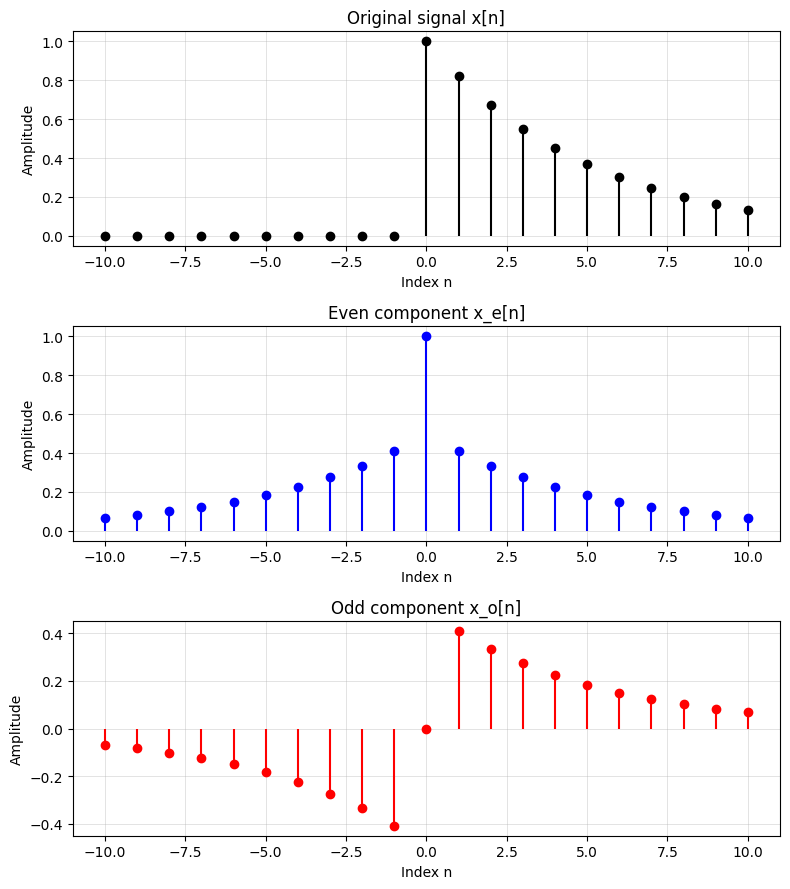

In [ ]:
if __name__ == "__main__":
    n = np.arange(-10, 11)

    # 테스트 신호 1: 인과적 지수형 신호, 테스트 신호 2: 이산 정현파
    x1 = np.where(n >= 0, 1.0, 0.0) * np.exp(-0.2 * np.maximum(n, 0))
    x2 = np.cos(2 * np.pi * n / 8.0)

    # (1) 짝-홀 분해
    x_even, x_odd = even_odd_decomposition(n, x1)

    # (2) 주기성 판별: 1장의 예시(Omega0 = pi/5)를 재사용
    Omega0_example = np.pi / 5
    periodic, N0 = is_periodic_discrete_sinusoid(Omega0_example)
    print(f"Omega0 = pi/5 인 정현파 -> 주기신호 여부: {periodic}, 기본주기 N = {N0}")

    # (3) 시스템 정의: 지연 시스템(선형/시불변)과 제곱 시스템(비선형)
    def system_delay(n, x):
        return shift_signal(n, x, 1)

    def system_square(n, x):
        return x ** 2

    lin_delay, ti_delay = verify_linearity_and_time_invariance(
        system_delay, n, x1, x2, a=2.0, b=-1.5, n0=3
    )
    lin_square, ti_square = verify_linearity_and_time_invariance(
        system_square, n, x1, x2, a=2.0, b=-1.5, n0=3
    )

    print(f"[지연 시스템 y[n]=x[n-1]] 선형성: {lin_delay}, 시불변성: {ti_delay}")
    print(f"[제곱 시스템 y[n]=x[n]^2 ] 선형성: {lin_square}, 시불변성: {ti_square}")

    # (4) 시각화
    fig, axes = plt.subplots(3, 1, figsize=(8, 9), facecolor='white')
    for ax in axes:
        ax.set_facecolor('white')

    axes[0].stem(n, x1, linefmt='k-', markerfmt='ko', basefmt=' ')
    axes[0].set_title('Original signal x[n]')
    axes[0].set_xlabel('Index n')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, linewidth=0.5, alpha=0.5)

    axes[1].stem(n, x_even, linefmt='b-', markerfmt='bo', basefmt=' ')
    axes[1].set_title('Even component x_e[n]')
    axes[1].set_xlabel('Index n')
    axes[1].set_ylabel('Amplitude')
    axes[1].grid(True, linewidth=0.5, alpha=0.5)

    axes[2].stem(n, x_odd, linefmt='r-', markerfmt='ro', basefmt=' ')
    axes[2].set_title('Odd component x_o[n]')
    axes[2].set_xlabel('Index n')
    axes[2].set_ylabel('Amplitude')
    axes[2].grid(True, linewidth=0.5, alpha=0.5)

    fig.tight_layout()
    plt.show()